###  Чем он таким занимается?

Агент призван помочь С-разработчику писать безопасные программы.

1. Писать и сохранять код в рабочую директорию.
2. Запускать clang с разными профилями (freestanding, sanitized, released...)
3. Прогонять стат. анализаторы (clang-tidy, cppcheck)
4. Читать и анализировать артефакты


### Зависимости

1. Установочный скрипт в setup.sh
2. Python зависимости в requirements.sh (установка включена в setuip.sh)
3. Базовая модель - gpt-oss20b


In [9]:
# Импорты 

import json
import os
import shlex
import subprocess
from pathlib import Path
from typing import Literal

from langchain.agents import create_agent
from langchain_ollama import ChatOllama
from langchain.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

In [10]:
# Настройки

WORKSPACE = Path.cwd() / "agent_misc"
WORKSPACE.mkdir(exist_ok=True)

MODEL_NAME = "gpt-oss:20b"
OLLAMA_BASE_URL = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
COMPILER = os.environ.get("CC", "clang")
C_STANDARD = "c18"

print(f"Workspace: {WORKSPACE}")
print(f"Ollama:    {OLLAMA_BASE_URL}")
print(f"Compiler:  {COMPILER}")
print(f"Model:     {MODEL_NAME}")

Workspace: /home/xarm86/hse/iad-applied/hw-1/react-langchain-agent/agent_misc
Ollama:    http://localhost:11434
Compiler:  clang
Model:     gpt-oss:20b


In [11]:
# Для безопасной разработки обычно используют подобный объем флагов
COMMON_WARNINGS = [
    f"-std={C_STANDARD}",
    "-Wall",
    "-Wextra",
    "-Wpedantic",
    "-Werror",
    "-Wcast-align",
    "-Wcast-qual",
    "-Wconversion",
    "-Wsign-conversion",
    "-Wshadow",
    "-Wformat=2",
    "-Wformat-security",
    "-Wnull-dereference",
    "-Wstrict-prototypes",
    "-Wmissing-prototypes",
    "-Wundef",
    "-Wuninitialized",
    "-Wswitch-enum",
    "-Wdouble-promotion",
    "-Wwrite-strings",
    "-Wvla",
    "-fno-common",

    "-Wno-unused",
    "-Wno-unused-parameter",
    "-Wno-unused-variable",
    "-Wno-unused-function",
    "-Wno-unused-label",
    "-Wno-unused-value",
    "-Wno-missing-field-initializers",
    "-Wno-sign-conversion",
    "-Wno-declaration-after-statement",
]

PROFILES = {
    "hosted_release": {
        "cflags": COMMON_WARNINGS + [
            "-O2",
            "-D_FORTIFY_SOURCE=3",
            "-fstack-protector-strong",
            "-fPIE",
        ],
        "ldflags": ["-Wl,-z,relro,-z,now", "-pie"],
        "note": "Для Linux/hosted production-сборки. Sanitizer-ы сюда не входят.",
    },
    "hosted_debug_sanitized": {
        "cflags": COMMON_WARNINGS + [
            "-O1",
            "-g3",
            "-fno-omit-frame-pointer",
            "-fsanitize=address,undefined",
        ],
        "ldflags": ["-fsanitize=address,undefined"],
        "note": "Для тестов и отладки. Не для прода.",
    },
    "freestanding_release": {
        "cflags": COMMON_WARNINGS + [
            "-O2",
            "-ffreestanding",
            "-fno-builtin",
            "-fdata-sections",
            "-ffunction-sections",
        ],
        "ldflags": ["-Wl,--gc-sections"],
        "note": "Для bare-metal / frteestanding среды; Linux hardening-флаги тут обычно неприменимы.",
    },
}

PROFILES

{'hosted_release': {'cflags': ['-std=c18',
   '-Wall',
   '-Wextra',
   '-Wpedantic',
   '-Werror',
   '-Wcast-align',
   '-Wcast-qual',
   '-Wconversion',
   '-Wsign-conversion',
   '-Wshadow',
   '-Wformat=2',
   '-Wformat-security',
   '-Wnull-dereference',
   '-Wstrict-prototypes',
   '-Wmissing-prototypes',
   '-Wundef',
   '-Wuninitialized',
   '-Wswitch-enum',
   '-Wdouble-promotion',
   '-Wwrite-strings',
   '-Wvla',
   '-fno-common',
   '-Wno-unused',
   '-Wno-unused-parameter',
   '-Wno-unused-variable',
   '-Wno-unused-function',
   '-Wno-unused-label',
   '-Wno-unused-value',
   '-Wno-missing-field-initializers',
   '-Wno-sign-conversion',
   '-Wno-declaration-after-statement',
   '-O2',
   '-D_FORTIFY_SOURCE=3',
   '-fstack-protector-strong',
   '-fPIE'],
  'ldflags': ['-Wl,-z,relro,-z,now', '-pie'],
  'note': 'Для Linux/hosted production-сборки. Sanitizer-ы сюда не входят.'},
 'hosted_debug_sanitized': {'cflags': ['-std=c18',
   '-Wall',
   '-Wextra',
   '-Wpedantic',
   

In [12]:
# Утилиты

def _safe_path(relative_path: str) -> Path:
    p = (WORKSPACE / relative_path).resolve()
    if not str(p).startswith(str(WORKSPACE.resolve())):
        raise ValueError("Path escapes workspace")
    return p


def _run(cmd: list[str], timeout: int = 30) -> dict:
    proc = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        timeout=timeout,
    )
    return {
        "cmd": cmd,
        "returncode": proc.returncode,
        "stdout": proc.stdout,
        "stderr": proc.stderr,
    }

In [13]:
@tool
def write_c_file(path: str, code: str) -> str:
    """Save C source code into a file inside the agent workspace."""

    print("TOOL: Running write file...")

    target = _safe_path(path)
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(code, encoding="utf-8")
    return f"Wrote {target.relative_to(WORKSPACE)} ({len(code)} bytes)"


@tool
def read_c_file(path: str) -> str:
    """Read a UTF-8 text file from the agent workspace."""

    print("TOOL: Running read text file...")

    target = _safe_path(path)
    return target.read_text(encoding="utf-8")


@tool
def list_workspace() -> str:
    """List files currently available in the agent workspace."""

    print("TOOL: Running list workspace...")

    files = []
    for p in sorted(WORKSPACE.rglob("*")):
        if p.is_file():
            files.append(str(p.relative_to(WORKSPACE)))
    return json.dumps(files, ensure_ascii=False, indent=2)

In [14]:
@tool
def compile_c_file(
    source_path: str,
    output_path: str = "build/a.out",
    profile: Literal["hosted_release", "hosted_debug_sanitized", "freestanding_release"] = "hosted_release",
    extra_cflags: str = "",
    extra_ldflags: str = "",
) -> str:
    """Compile a C file with one of the predefined safety-oriented flag profiles.
    """

    print("TOOL: Running compile file...")

    src = _safe_path(source_path)
    out = _safe_path(output_path)
    out.parent.mkdir(parents=True, exist_ok=True)

    selected = PROFILES[profile]
    extra_cflags_list = shlex.split(extra_cflags)
    extra_ldflags_list = shlex.split(extra_ldflags)

    compile_only_flags = {"-c", "-S", "-E", "-fsyntax-only"}
    is_link_stage = not any(flag in extra_cflags_list for flag in compile_only_flags)

    cmd = [
        COMPILER,
        *selected["cflags"],
        *extra_cflags_list,
        str(src),
        "-o",
        str(out),
    ]

    if is_link_stage:
        cmd.extend(selected["ldflags"])
        cmd.extend(extra_ldflags_list)

    result = _run(cmd, timeout=60)
    payload = {
        "profile": profile,
        "profile_note": selected["note"],
        "is_link_stage": is_link_stage,
        "command": " ".join(shlex.quote(x) for x in cmd),
        "returncode": result["returncode"],
        "stdout": result["stdout"],
        "stderr": result["stderr"],
        "artifact": str(out.relative_to(WORKSPACE)) if out.exists() else None,
    }
    return json.dumps(payload, ensure_ascii=False, indent=2)

In [15]:
@tool
def analyze_c_file(
    source_path: str,
    profile: Literal["hosted_release", "hosted_debug_sanitized", "freestanding_release"] = "hosted_release",
) -> str:
    """Run clang-tidy and cppcheck against a C source file in the workspace."""

    print("TOOL: Running analyze file...")

    src = _safe_path(source_path)
    selected = PROFILES[profile]

    clang_tidy_cmd = [
        "clang-tidy",
        str(src),
        "--",
        *selected["cflags"],
    ]
    cppcheck_cmd = [
        "cppcheck",
        "--enable=warning,style,performance,portability",
        "--std=c11",
        "--language=c",
        str(src),
    ]

    clang_tidy = _run(clang_tidy_cmd, timeout=60)
    cppcheck = _run(cppcheck_cmd, timeout=60)

    payload = {
        "profile": profile,
        "clang_tidy": clang_tidy,
        "cppcheck": cppcheck,
    }
    return json.dumps(payload, ensure_ascii=False, indent=2)

In [16]:
@tool
def run_c_file(
    binary_path: str,
    cli_args: str = "",
    timeout_sec: int = 3,
) -> str:
    """Run a compiled binary from the build directory with timeout and capture stdout/stderr."""

    print("TOOL: Running run file...")

    binary = _safe_path(binary_path)

    if not binary.exists():
        return json.dumps({
            "ok": False,
            "error": f"Binary does not exist: {binary}"
        }, ensure_ascii=False, indent=2)

    if not binary.is_file():
        return json.dumps({
            "ok": False,
            "error": f"Not a file: {binary}"
        }, ensure_ascii=False, indent=2)

    build_dir_resolved = WORKSPACE.resolve()
    if not str(binary).startswith(str(build_dir_resolved)):
        return json.dumps({
            "ok": False,
            "error": "Only binaries inside workspace may be executed"
        }, ensure_ascii=False, indent=2)

    cmd = [str(binary), *shlex.split(cli_args)]

    try:
        result = subprocess.run(
            cmd,
            cwd=str(WORKSPACE),
            capture_output=True,
            text=True,
            timeout=timeout_sec,
            check=False,
            env={
                "PATH": os.environ.get("PATH", ""),
            },
        )
    except subprocess.TimeoutExpired:
        return json.dumps({
            "ok": False,
            "command": cmd,
            "error": f"Execution timed out after {timeout_sec} seconds"
        }, ensure_ascii=False, indent=2)
    except Exception as e:
        return json.dumps({
            "ok": False,
            "command": cmd,
            "error": str(e)
        }, ensure_ascii=False, indent=2)

    stdout = result.stdout[:8000]
    stderr = result.stderr[:8000]

    return json.dumps({
        "ok": result.returncode == 0,
        "command": cmd,
        "returncode": result.returncode,
        "stdout": stdout,
        "stderr": stderr,
    }, ensure_ascii=False, indent=2)

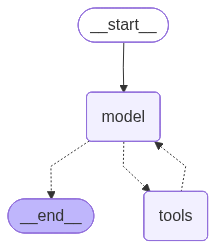

In [17]:
SYSTEM_PROMPT = """
You are a careful C engineering agent.

Rules:
1. Work only inside the local workspace.
2. Prefer small, reviewable changes.
3. Before compilation, explain which profile is appropriate and why.
4. For Linux user-space production builds, prefer hosted_release.
5. For debugging and bug hunting, prefer hosted_debug_sanitized.
6. For bare-metal / freestanding code, prefer freestanding_release.
7. Never claim that compiler flags alone make software safety-critical compliant.
8. When compilation fails, inspect diagnostics and fix the code or explain the issue.
9. Do not execute compiled binaries automatically.
10. Prefer explicit, standards-friendly C18 code with prototypes and no VLA usage.
11. When a suitable tool exists, you must call the tool instead of describing the call.
12. Never output fake tool-call JSON in message content.
13. Do not write {"name": "...", "arguments": ...} as plain text.
14. For ABI/layout questions:
    - do not guess final sizeof immediately,
    - compute offsets step by step,
    - if clang record-layout dump is available, use it as the source of truth,
    - if compiler-based layout evidence conflicts with your reasoning, prefer the compiler output.
""".strip()

llm = ChatOllama(
    model=MODEL_NAME,
    base_url=OLLAMA_BASE_URL,
    temperature=0,
    num_ctx=8192,
)

checkpointer = InMemorySaver()

agent = create_agent(
    model=llm,
    system_prompt=SYSTEM_PROMPT,
    tools=[write_c_file, read_c_file, list_workspace, compile_c_file, analyze_c_file, run_c_file],
    checkpointer=checkpointer,
)

agent

In [84]:
# Быстрая ручная проверка без агента
sample_code = """
#include <stdint.h>
#include <stdio.h>

static uint16_t saturating_add_u16(uint16_t a, uint16_t b)
{
    uint32_t sum = (uint32_t)a + (uint32_t)b;
    return (sum > UINT16_MAX) ? UINT16_MAX : (uint16_t)sum;
}

int main(void){
    uint32_t res = saturating_add_u16(16U, 8U);
    printf("res: %u", res);
    return 0;
}

"""

print(write_c_file.invoke({"path": "test.c", "code": sample_code}))
print(analyze_c_file.invoke({"source_path": "test.c", "profile": "hosted_release"}))
print(compile_c_file.invoke({
    "source_path": "test.c",
    "output_path": "test",
    "profile": "hosted_release",
}))
print(run_c_file.invoke({
    "binary_path": "test",
    "cli_args": ""
}))

TOOL: Running write file...
Wrote test.c (320 bytes)
TOOL: Running analyze file...
{
  "profile": "hosted_release",
  "clang_tidy": {
    "cmd": [
      "clang-tidy",
      "/home/xarm86/hse/iad-applied/hw-1/react-langchain-agent/agent_misc/test.c",
      "--",
      "-std=c18",
      "-Wall",
      "-Wextra",
      "-Wpedantic",
      "-Werror",
      "-Wcast-align",
      "-Wcast-qual",
      "-Wconversion",
      "-Wsign-conversion",
      "-Wshadow",
      "-Wformat=2",
      "-Wformat-security",
      "-Wnull-dereference",
      "-Wstrict-prototypes",
      "-Wmissing-prototypes",
      "-Wundef",
      "-Wuninitialized",
      "-Wswitch-enum",
      "-Wdouble-promotion",
      "-Wwrite-strings",
      "-Wvla",
      "-fno-common",
      "-Wno-unused",
      "-Wno-unused-parameter",
      "-Wno-unused-variable",
      "-Wno-unused-function",
      "-Wno-unused-label",
      "-Wno-unused-value",
      "-Wno-missing-field-initializers",
      "-Wno-sign-conversion",
      "-Wno-decl

In [85]:
# Агентный сценарий
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Create a C file with a safe uint32_t saturating add function and call it zero_test, "
                    "save it, analyze it, and compile it with the appropriate production profile. "
                    "Then summarize diagnostics and the exact compile command."
                ),
            }
        ]
    },
    config={"configurable": {"thread_id": "test-0"}},
)

for m in response["messages"]:
    print(f"[{m.type.upper()}] {m.content}")

TOOL: Running write file...
TOOL: Running analyze file...
TOOL: Running compile file...
TOOL: Running write file...
TOOL: Running analyze file...
TOOL: Running compile file...
[HUMAN] Create a C file with a safe uint32_t saturating add function and call it zero_test, save it, analyze it, and compile it with the appropriate production profile. Then summarize diagnostics and the exact compile command.
[AI] 
[TOOL] Wrote sat_add.c (441 bytes)
[AI] 
[TOOL] Error invoking tool 'analyze_c_file' with kwargs {'profile': 'clang_tidy_cppcheck', 'source_path': 'sat_add.c'} with error:
 profile: Input should be 'hosted_release', 'hosted_debug_sanitized' or 'freestanding_release'
 Please fix the error and try again.
[AI] 
[TOOL] {
  "profile": "hosted_release",
  "clang_tidy": {
    "cmd": [
      "clang-tidy",
      "/home/xarm86/hse/iad-applied/hw-1/react-langchain-agent/agent_misc/sat_add.c",
      "--",
      "-std=c18",
      "-Wall",
      "-Wextra",
      "-Wpedantic",
      "-Werror",
     

### Больше примеров! 

Разговариваю с моделью на английском чтобы ей было комфортно.

In [86]:
# Пример 1 - размер структуры

prompt_sizeof_x86 = r'''
Assume a 32-bit x86 ILP32 ABI.

Do not execute compiled binaries.
Compute the expected sizeof and field offsets for this structure, explain padding and alignment,
and then save the code and analyze it. If you compile, do it only for static checking and explain
that the ABI assumption is ILP32 x86.

```c
#include <stdint.h>

typedef struct SensorFrame {
    uint8_t  tag;
    uint32_t counter;
    uint16_t voltage_mv;
    uint8_t  status;
} SensorFrame;
```

Return:
1. expected offsetof for every field,
2. expected sizeof(SensorFrame),
3. short explanation why.
'''

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt_sizeof_x86}]},
    config={"configurable": {"thread_id": "demo-sizeof-x86"}},
)

for m in response["messages"]:
    print(f"[{m.type.upper()}] {m.content}")

TOOL: Running write file...
TOOL: Running analyze file...
[HUMAN] 
Assume a 32-bit x86 ILP32 ABI.

Do not execute compiled binaries.
Compute the expected sizeof and field offsets for this structure, explain padding and alignment,
and then save the code and analyze it. If you compile, do it only for static checking and explain
that the ABI assumption is ILP32 x86.

```c
#include <stdint.h>

typedef struct SensorFrame {
    uint8_t  tag;
    uint32_t counter;
    uint16_t voltage_mv;
    uint8_t  status;
} SensorFrame;
```

Return:
1. expected offsetof for every field,
2. expected sizeof(SensorFrame),
3. short explanation why.

[AI] 
[TOOL] Wrote sensor_frame.c (311 bytes)
[AI] 
[TOOL] Error invoking tool 'analyze_c_file' with kwargs {'profile': 'static', 'source_path': 'sensor_frame.c'} with error:
 profile: Input should be 'hosted_release', 'hosted_debug_sanitized' or 'freestanding_release'
 Please fix the error and try again.
[AI] 
[TOOL] {
  "profile": "hosted_release",
  "clang_tidy

In [87]:
# Пример 2 - утечка памяти!

prompt_memleak = r'''
Find the memory leak in this code. Explain the ownership bug, point to the exact path where memory
is lost, and suggest the smallest safe fix. Save the file, analyze it, and compile it with the
appropriate debug/sanitizer profile for bug hunting. Do not run the program.

```c
#include <stdlib.h>
#include <string.h>

char *make_message(const char *src)
{
    char *buf = (char *)malloc(128);
    if (buf == NULL) {
        return NULL;
    }

    if (strlen(src) > 100U) {
        return NULL;
    }

    strcpy(buf, src);
    return buf;
}
```

In the answer, state clearly whether there are problems besides the leak.
'''

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt_memleak}]},
    config={"configurable": {"thread_id": "demo-memleak"}},
)

for m in response["messages"]:
    print(f"[{m.type.upper()}] {m.content}")

TOOL: Running write file...
TOOL: Running analyze file...
[HUMAN] 
Find the memory leak in this code. Explain the ownership bug, point to the exact path where memory
is lost, and suggest the smallest safe fix. Save the file, analyze it, and compile it with the
appropriate debug/sanitizer profile for bug hunting. Do not run the program.

```c
#include <stdlib.h>
#include <string.h>

char *make_message(const char *src)
{
    char *buf = (char *)malloc(128);
    if (buf == NULL) {
        return NULL;
    }

    if (strlen(src) > 100U) {
        return NULL;
    }

    strcpy(buf, src);
    return buf;
}
```

In the answer, state clearly whether there are problems besides the leak.

[AI] 
[TOOL] Wrote leak.c (265 bytes)
[AI] 
[TOOL] Error invoking tool 'analyze_c_file' with kwargs {'profile': 'clang_tidy', 'source_path': 'leak.c'} with error:
 profile: Input should be 'hosted_release', 'hosted_debug_sanitized' or 'freestanding_release'
 Please fix the error and try again.
[AI] 
[TOOL] {
 

In [88]:
# Пример 3 - попробуем найти гонку! 

prompt_race = r'''
Find the data race in this code. Explain which shared state is unsafely accessed, why this is a race,
and show the smallest production-reasonable fix. Save and analyze the file. Compilation is optional,
but do not execute the binary.

```c
#include <pthread.h>
#include <stdint.h>

static uint32_t g_counter = 0;

static void *worker(void *arg)
{
    (void)arg;
    for (uint32_t i = 0; i < 1000000U; ++i) {
        g_counter++;
    }
    return 0;
}

int main(void)
{
    pthread_t t1;
    pthread_t t2;

    pthread_create(&t1, 0, worker, 0);
    pthread_create(&t2, 0, worker, 0);

    pthread_join(t1, 0);
    pthread_join(t2, 0);
    return 0;
}
```

Prefer a fix based on pthread mutex or C11 atomics and explain the tradeoff.
'''

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt_race}]},
    config={"configurable": {"thread_id": "demo-race"}},
)

for m in response["messages"]:
    print(f"[{m.type.upper()}] {m.content}")

TOOL: Running write file...
[HUMAN] 
Find the data race in this code. Explain which shared state is unsafely accessed, why this is a race,
and show the smallest production-reasonable fix. Save and analyze the file. Compilation is optional,
but do not execute the binary.

```c
#include <pthread.h>
#include <stdint.h>

static uint32_t g_counter = 0;

static void *worker(void *arg)
{
    (void)arg;
    for (uint32_t i = 0; i < 1000000U; ++i) {
        g_counter++;
    }
    return 0;
}

int main(void)
{
    pthread_t t1;
    pthread_t t2;

    pthread_create(&t1, 0, worker, 0);
    pthread_create(&t2, 0, worker, 0);

    pthread_join(t1, 0);
    pthread_join(t2, 0);
    return 0;
}
```

Prefer a fix based on pthread mutex or C11 atomics and explain the tradeoff.

[AI] 
[TOOL] Wrote race.c (963 bytes)
[AI] **Data‑race analysis**

| Thread | Operation on `g_counter` |
|--------|--------------------------|
| 1      | read → increment → write |
| 2      | read → increment → write |

Both thre

In [18]:
# Пример 4 - попробуем найти опасность в коде с упакованной структурой!

prompt_packed = r'''
Explain why this code is risky on some targets even if it compiles. Focus on packed layout,
alignment, portability, and safety-critical concerns. Suggest a safer alternative API.
Save and analyze the code. Compile if useful, but do not run it.

```c
#include <stdint.h>

typedef struct __attribute__((packed)) PacketHeader {
    uint8_t  type;
    uint32_t length;
} PacketHeader;

uint32_t read_length(const uint8_t *raw)
{
    const PacketHeader *hdr = (const PacketHeader *)raw;
    return hdr->length;
}
```

In the answer:
1. explain the alignment risk,
2. explain why direct casting from raw bytes is fragile,
3. propose a safer version using memcpy or explicit byte decoding.
'''

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt_packed}]},
    config={"configurable": {"thread_id": "demo-packed"}},
)
for m in response["messages"]:
    print("TYPE:", m.type)
    print("CONTENT:", m.content)
    print("TOOL_CALLS:", getattr(m, "tool_calls", None))
    print("ADDITIONAL_KWARGS:", getattr(m, "additional_kwargs", None))
    print("-" * 80)

TOOL: Running write file...
TOOL: Running compile file...
TYPE: human
CONTENT: 
Explain why this code is risky on some targets even if it compiles. Focus on packed layout,
alignment, portability, and safety-critical concerns. Suggest a safer alternative API.
Save and analyze the code. Compile if useful, but do not run it.

```c
#include <stdint.h>

typedef struct __attribute__((packed)) PacketHeader {
    uint8_t  type;
    uint32_t length;
} PacketHeader;

uint32_t read_length(const uint8_t *raw)
{
    const PacketHeader *hdr = (const PacketHeader *)raw;
    return hdr->length;
}
```

In the answer:
1. explain the alignment risk,
2. explain why direct casting from raw bytes is fragile,
3. propose a safer version using memcpy or explicit byte decoding.

TOOL_CALLS: None
ADDITIONAL_KWARGS: {}
--------------------------------------------------------------------------------
TYPE: ai
CONTENT: 
TOOL_CALLS: [{'name': 'write_c_file', 'args': {'code': '#include <stdint.h>\n\n// Original packed